## 1. Importações Iniciais

In [1]:
# Instalação das dependências necessárias
!pip install numpy pandas matplotlib seaborn scipy wfdb scikit-learn

In [2]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from helper_code import find_records, load_header, get_age, get_sex, get_label

## 2. Configuração das Pastas

In [3]:
# Caminhos para os datasets
code15_output = "code15_output"
ptbxl_output = "ptbxl_output"
samitrop_output = "samitrop_output"

# Lista de todos os registros
all_datasets = [code15_output, ptbxl_output, samitrop_output]

In [4]:
print(all_datasets)

['code15_output', 'ptbxl_output', 'samitrop_output']


## 3. Função para Carregar Dados
Crie uma função para carregar os dados de todos os conjuntos de dados:

In [19]:
def load_all_records(datasets):
    records_list = []
    for dataset in datasets:
        # Encontra todos os registros no dataset
        records = find_records(dataset)
        for record in records:
            # Carrega o cabeçalho (.hea)
            header_file = os.path.join(dataset, record + ".hea")
            header = load_header(header_file)
            
            # Extrai informações do cabeçalho
            age = get_age(header)
            sex = get_sex(header)
            label = get_label(header, allow_missing=True)  # Permitindo rótulos ausentes
            
            # Adiciona à lista de registros
            records_list.append({
                "record": record,
                "dataset": dataset,
                "age": age,
                "sex": sex,
                "label": label
            })
    return pd.DataFrame(records_list)

# Carrega todos os registros
df_records = load_all_records(all_datasets)
print("Total Records Loaded:", len(df_records))

Total Records Loaded: 365369


In [10]:
header_example = load_header("/home/mpsilva/Documentos/Mateus-documentos/Chagas Disease/python-example-2025/code15_output/exams_part0/113.hea")

In [11]:
print(header_example)

113 12 400 4096
113.dat 16 1000(0)/mV 16 0 7767 28904 0 I
113.dat 16 1000(0)/mV 16 0 2820 -4132 0 II
113.dat 16 1000(0)/mV 16 0 -4947 32499 0 III
113.dat 16 1000(0)/mV 16 0 -5290 18601 0 AVR
113.dat 16 1000(0)/mV 16 0 6357 -9558 0 AVL
113.dat 16 1000(0)/mV 16 0 -1059 -23504 0 AVF
113.dat 16 1000(0)/mV 16 0 4451 27243 0 V1
113.dat 16 1000(0)/mV 16 0 3186 15474 0 V2
113.dat 16 1000(0)/mV 16 0 4451 28365 0 V3
113.dat 16 1000(0)/mV 16 0 3826 22578 0 V4
113.dat 16 1000(0)/mV 16 0 3948 -12925 0 V5
113.dat 16 1000(0)/mV 16 0 4367 -14130 0 V6
# Age: 68
# Sex: Female
# Chagas label: False
# Source: CODE-15%



## 4. Análise Exploratória dos Dados


### a. Distribuição por Classes

/tmp/ipykernel_205401/432932190.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="label", data=df_records, palette=colors)


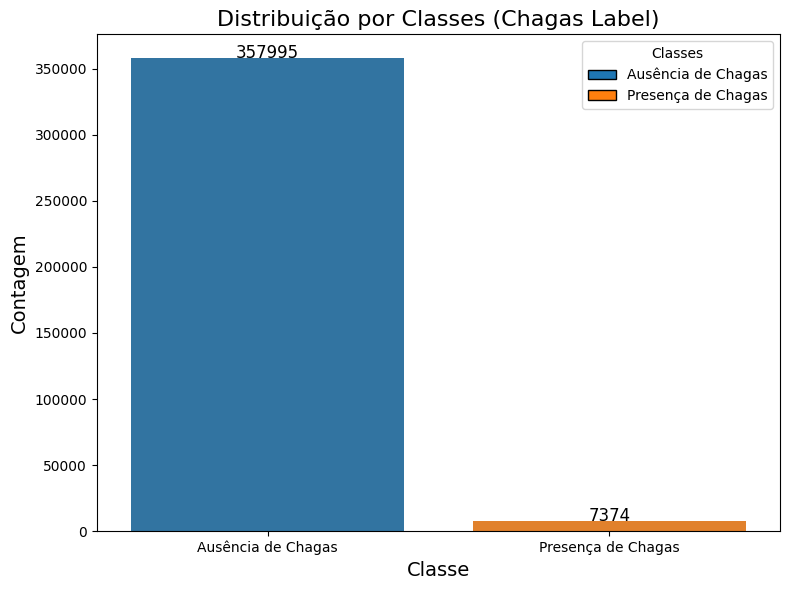

In [68]:
plt.figure(figsize=(8, 6))
# Define cores personalizadas para cada classe
colors = ["#1f77b4", "#ff7f0e"]  # Azul para "Ausência de Chagas", Laranja para "Presença de Chagas"
ax = sns.countplot(x="label", data=df_records, palette=colors)

# Adicionar título e rótulos dos eixos
plt.title("Distribuição por Classes (Chagas Label)", fontsize=16)
plt.xlabel("Classe", fontsize=14)
plt.ylabel("Contagem", fontsize=14)

# Substituir os valores 0 e 1 por descrições textuais no eixo x
plt.xticks(ticks=[0, 1], labels=["Ausência de Chagas", "Presença de Chagas"])

# Adicionar os valores de cada barra acima delas
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 3, f'{int(height)}', ha='center', fontsize=12)

# Adicionar legenda com as cores correspondentes
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='black', label="Ausência de Chagas"),
    Patch(facecolor=colors[1], edgecolor='black', label="Presença de Chagas")
]
plt.legend(handles=legend_elements, title="Classes", loc="upper right")

plt.tight_layout()  # Ajusta o layout para evitar sobreposição
plt.show()

### a0. Plotagem da Presença de Doenças de Chagas

Total Records with Chagas Disease: 7374
Total Records without Chagas Disease: 357995


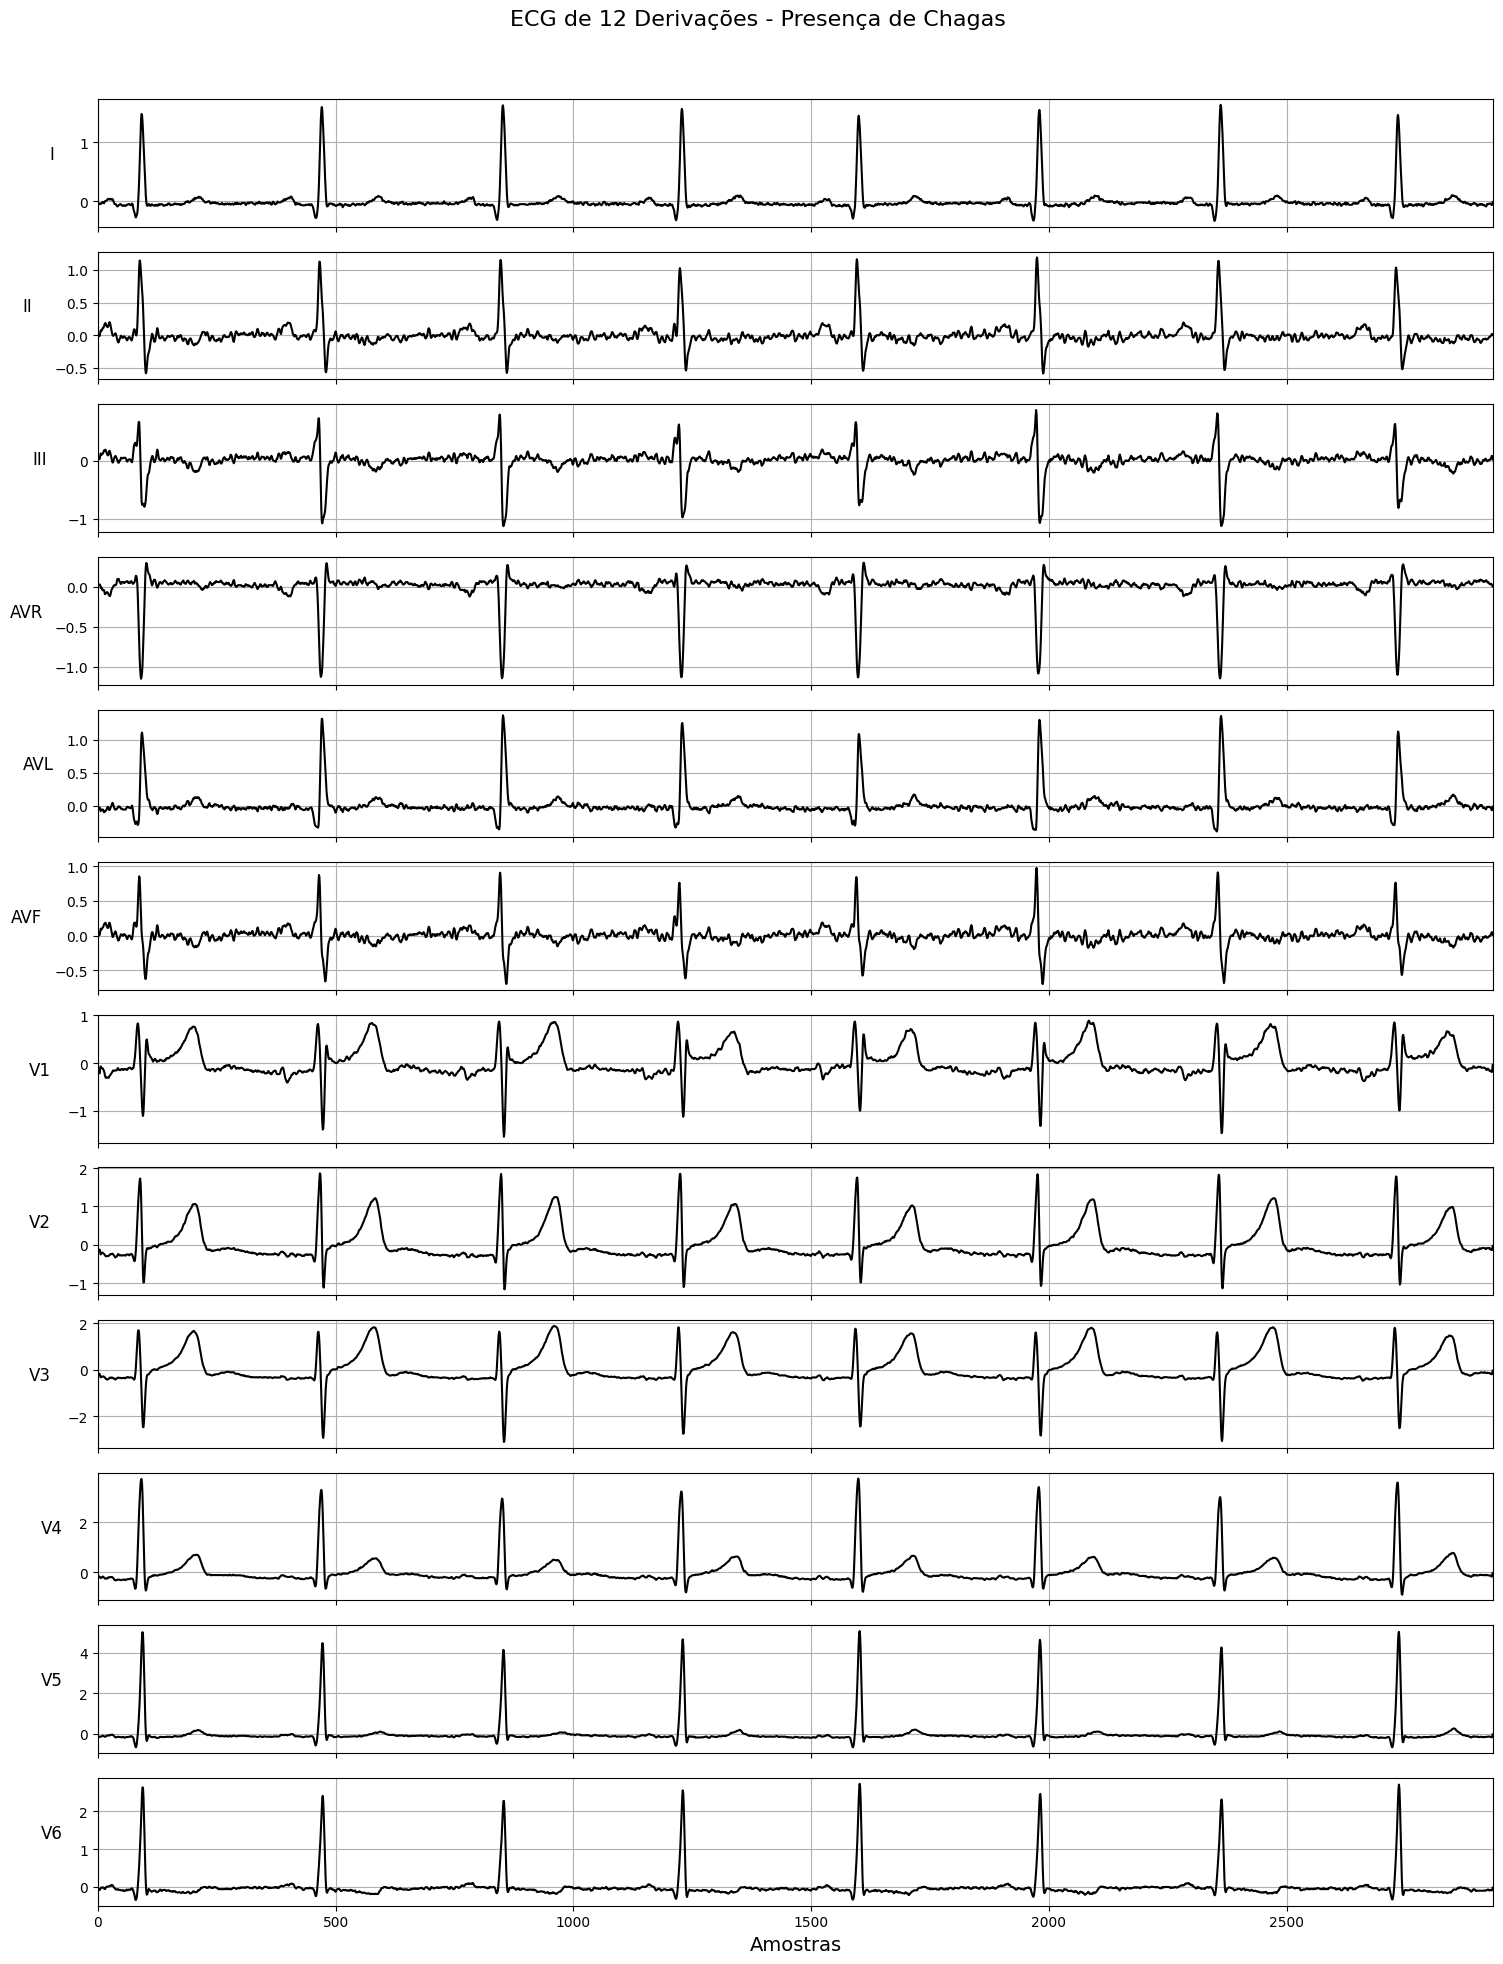

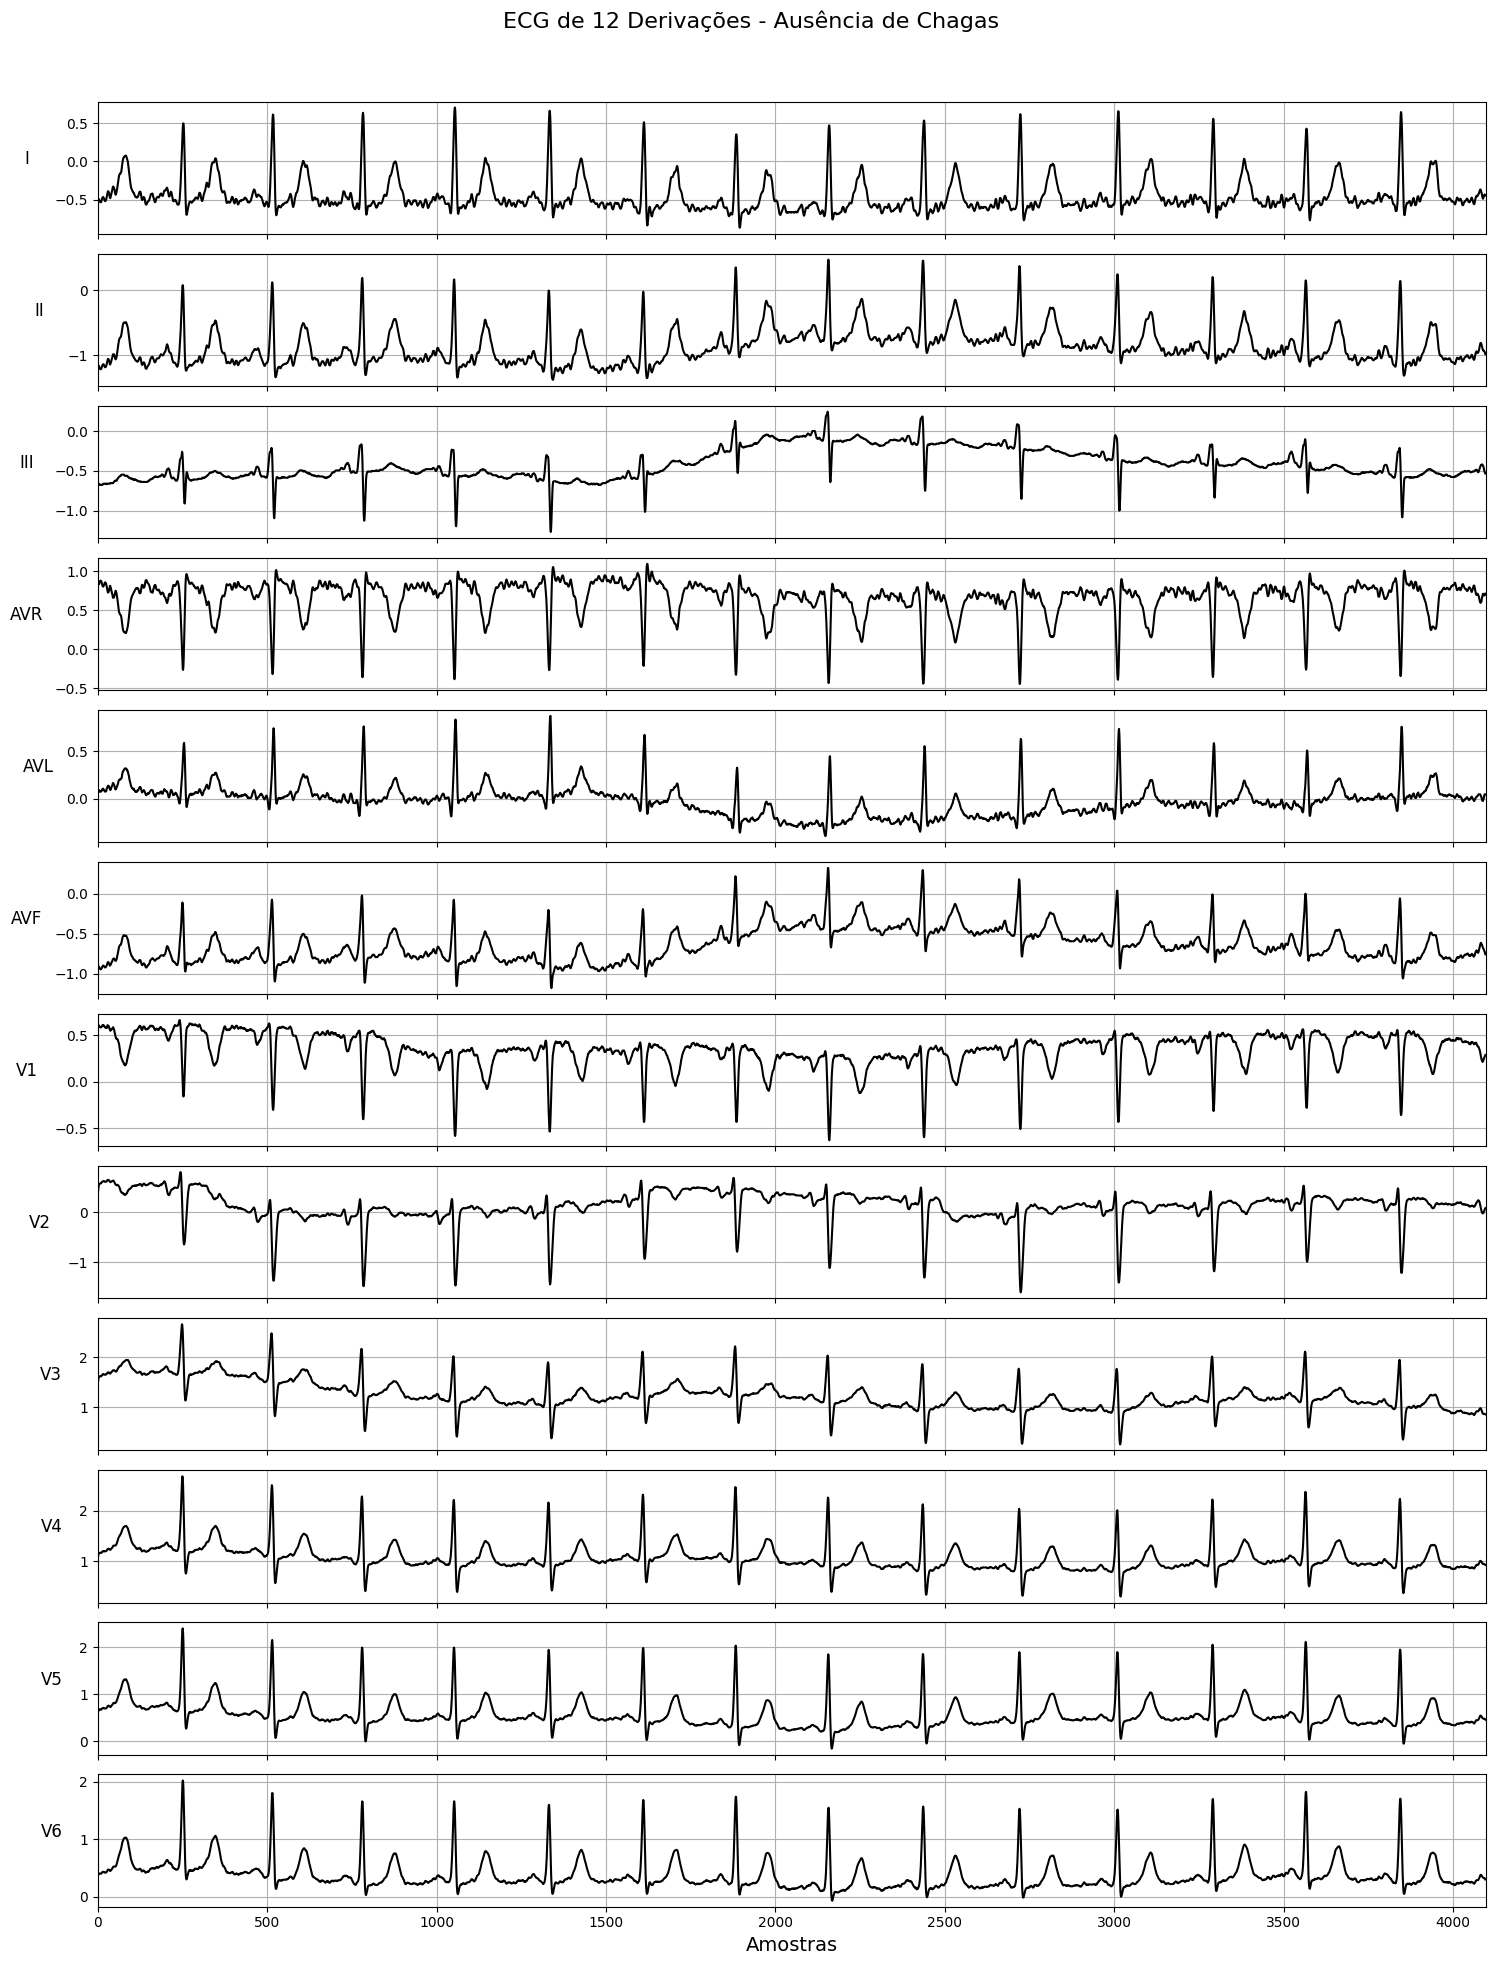

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import wfdb  # Biblioteca para manipulação de sinais ECG

# Filtra os dados para retornar apenas os registros com a presença da doença de Chagas
df_chagas = df_records[df_records['label'] == 1]  # Presença de Chagas
df_no_chagas = df_records[df_records['label'] == 0]  # Ausência de Chagas

print("Total Records with Chagas Disease:", len(df_chagas))
print("Total Records without Chagas Disease:", len(df_no_chagas))

# Seleciona um exemplo de cada classe (Chagas e Não Chagas)
example_chagas = df_chagas.iloc[1]  # Primeiro registro com Chagas
example_no_chagas = df_no_chagas.iloc[0]  # Primeiro registro sem Chagas

# Função para plotar o ECG de 12 derivações
def plot_ecg_12_leads(record_path, record_name, title):
    # Carrega o sinal ECG e os metadados
    record = wfdb.rdrecord(os.path.join(record_path, record_name))
    signals = record.p_signal
    leads = record.sig_name
    
    # Verifica se há 12 derivações
    if len(leads) != 12:
        print(f"O registro {record_name} não possui 12 derivações.")
        return
    
    # Configura o layout do gráfico
    fig, axes = plt.subplots(12, 1, figsize=(15, 20), sharex=True)
    fig.suptitle(title, fontsize=16)
    
    # Plota cada derivação
    for i in range(12):
        axes[i].plot(signals[:, i], color='black')
        axes[i].set_ylabel(leads[i], rotation=0, labelpad=20, fontsize=12)
        axes[i].grid(True)
        axes[i].set_xlim(0, len(signals[:, i]))
    
    axes[-1].set_xlabel("Amostras", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajusta o layout para evitar sobreposição
    plt.show()

# Plota o ECG para um caso com Chagas
plot_ecg_12_leads(
    record_path=example_chagas['dataset'],
    record_name=example_chagas['record'],
    title="ECG de 12 Derivações - Presença de Chagas"
)

# Plota o ECG para um caso sem Chagas
plot_ecg_12_leads(
    record_path=example_no_chagas['dataset'],
    record_name=example_no_chagas['record'],
    title="ECG de 12 Derivações - Ausência de Chagas"
)

In [7]:
print(df_chagas)

                     record          dataset   age     sex  label
89      exams_part0/1009988    code15_output  63.0  Female      1
151       exams_part0/10163    code15_output  33.0    Male      1
187     exams_part0/1020143    code15_output  57.0  Female      1
194      exams_part0/102085    code15_output  83.0  Female      1
195     exams_part0/1020860    code15_output  84.0  Female      1
...                     ...              ...   ...     ...    ...
365364                96278  samitrop_output  74.0  Female      1
365365                97425  samitrop_output  61.0    Male      1
365366                98580  samitrop_output  73.0  Female      1
365367                99398  samitrop_output  55.0  Female      1
365368                99671  samitrop_output  68.0  Female      1

[7374 rows x 5 columns]


In [15]:
!pip install peakutils

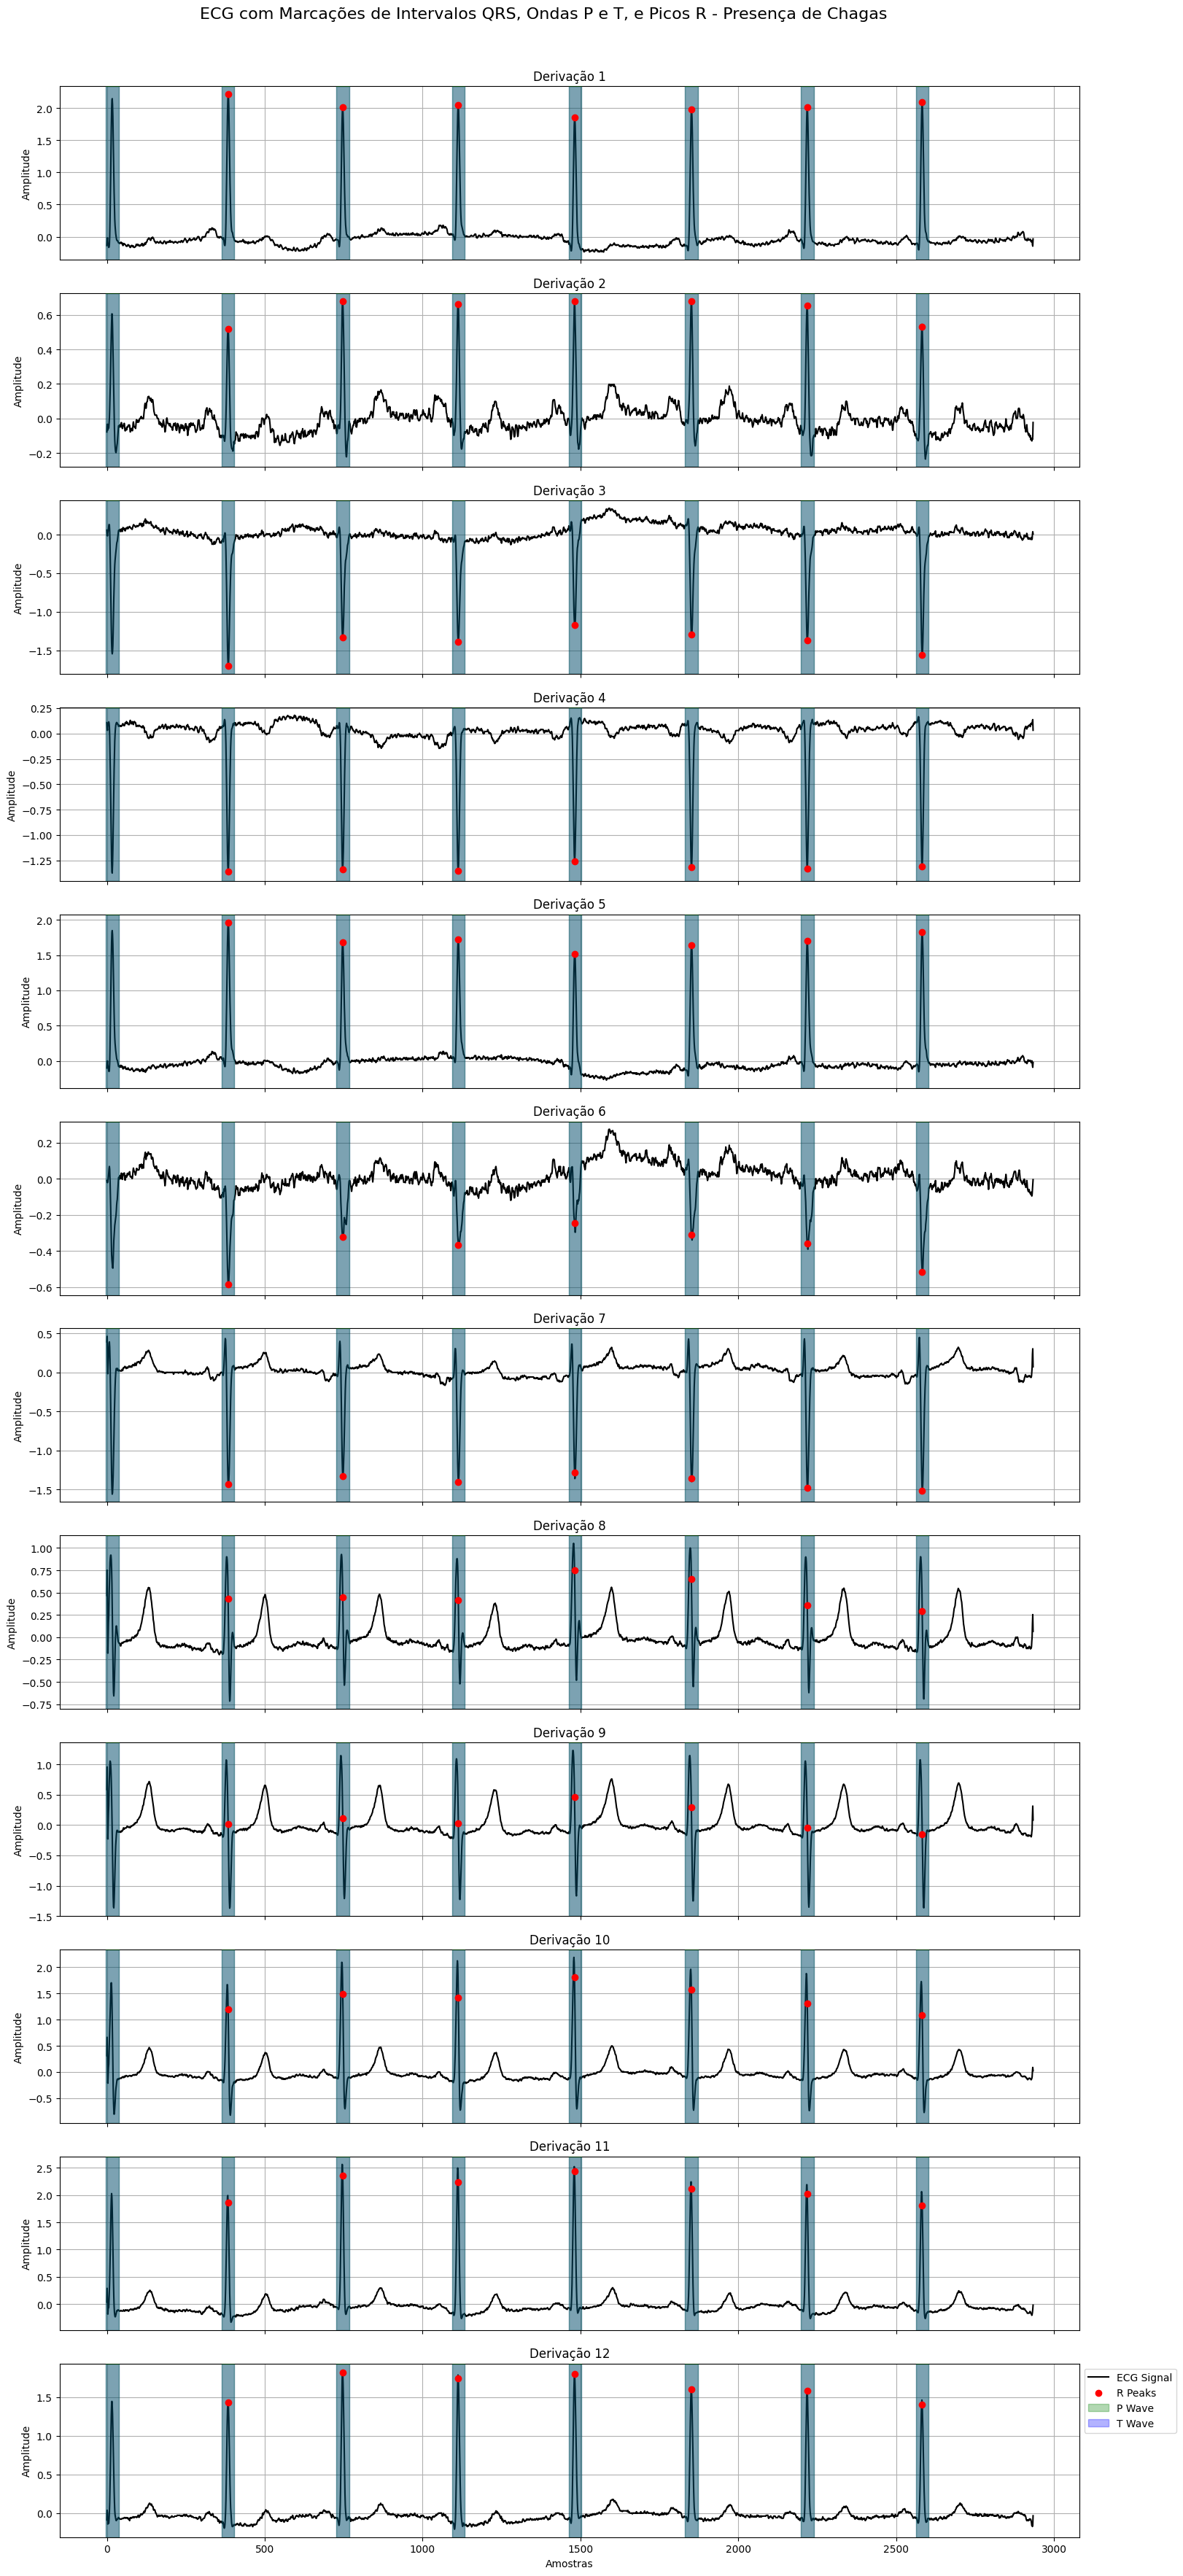

In [30]:
# Função para plotar os gráficos com as marcações
def plot_all_leads(features, title, fs):
    num_leads = len(features)
    fig, axes = plt.subplots(num_leads, 1, figsize=(15, 3 * num_leads), sharex=True)
    
    # Extrai as informações da primeira derivação (serão usadas para todas as outras)
    first_feature = features[0]
    r_peaks = first_feature["r_peaks"]
    qrs_onsets = first_feature["qrs_onsets"]
    qrs_offsets = first_feature["qrs_offsets"]
    t_waves = first_feature["t_waves"]
    p_waves = first_feature["p_waves"]
    
    for i, feature in enumerate(features):
        ecg_signal = feature["ecg_signal"]
        
        ax = axes[i] if num_leads > 1 else axes
        ax.plot(ecg_signal, color='black', label="ECG Signal")
        
        # Marca os picos R
        if len(r_peaks) > 0:
            ax.scatter(r_peaks, ecg_signal[r_peaks], color='red', label="R Peaks", zorder=5)
        
        # Marca o intervalo QRS (amarelo)
        for onset, offset in zip(qrs_onsets, qrs_offsets):
            ax.axvspan(onset, offset, color='yellow', alpha=0.3, label="QRS Region" if onset == qrs_onsets[0] else None, zorder=4)
        
        # Marca as ondas P (verde)
        if len(p_waves) > 0:
            for p_wave in p_waves:
                ax.axvspan(p_wave - int(0.05 * fs), p_wave + int(0.05 * fs), color='green', alpha=0.3, label="P Wave" if p_wave == p_waves[0] else None, zorder=3)
        
        # Marca as ondas T (azul)
        if len(t_waves) > 0:
            for t_wave in t_waves:
                ax.axvspan(t_wave - int(0.05 * fs), t_wave + int(0.05 * fs), color='blue', alpha=0.3, label="T Wave" if t_wave == t_waves[0] else None, zorder=2)
        
        ax.set_title(f"Derivação {i + 1}")
        ax.set_ylabel("Amplitude")
        ax.grid()
    
    plt.xlabel("Amostras")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.suptitle(title, fontsize=16)
    plt.legend(loc="upper right", bbox_to_anchor=(1.1, 1))
    plt.show()

# Função para extrair as características
def extract_ecg_features(record_path, record_name):
    # Carrega o sinal ECG
    record = wfdb.rdrecord(os.path.join(record_path, record_name))
    signals = record.p_signal
    fs = record.fs  # Frequência de amostragem
    
    # Lista para armazenar os resultados de todas as derivações
    all_features = []
    
    # Itera sobre todas as derivações
    for lead_index in range(signals.shape[1]):
        ecg_signal = signals[:, lead_index]
        
        # Processa o sinal ECG usando Biosppy
        out = ecg.ecg(signal=ecg_signal, sampling_rate=fs, show=False)
        
        # Extrai os picos R
        r_peaks = out['rpeaks']
        
        # Verifica se as chaves 'qrs_onsets' e 'qrs_offsets' estão disponíveis
        qrs_onsets = out['qrs_onsets'] if 'qrs_onsets' in out.keys() else []
        qrs_offsets = out['qrs_offsets'] if 'qrs_offsets' in out.keys() else []
        
        # Extrai as ondas T e P (se disponíveis)
        t_waves = out['t_waves'] if 't_waves' in out.keys() else []
        p_waves = out['p_waves'] if 'p_waves' in out.keys() else []
        
        # Se as ondas T e P não forem detectadas pelo Biosppy, usa detecção manual
        if len(t_waves) == 0:
            t_waves, _ = find_peaks(ecg_signal, height=np.max(ecg_signal) * 0.3, distance=fs * 0.2)
        if len(p_waves) == 0:
            p_waves, _ = find_peaks(ecg_signal, height=np.max(ecg_signal) * 0.1, distance=fs * 0.2)
        
        # Armazena os resultados para esta derivação
        all_features.append({
            "lead_index": lead_index,
            "ecg_signal": ecg_signal,
            "r_peaks": r_peaks,
            "qrs_onsets": qrs_onsets,
            "qrs_offsets": qrs_offsets,
            "t_waves": t_waves,
            "p_waves": p_waves
        })
    
    return all_features, fs

# Filtra o DataFrame para registros com presença de Chagas
df_chagas = df_records[df_records['label'] == 1]

# Seleciona um exemplo com Chagas
example_chagas = df_chagas.iloc[0]

# Extrai os recursos do ECG
record_path = example_chagas['dataset']
record_name = example_chagas['record']

# Extrai as características de todas as derivações e a frequência de amostragem
all_features, fs = extract_ecg_features(record_path, record_name)

# Plota os gráficos com as marcações para todas as derivações
plot_all_leads(
    features=all_features,
    title="ECG com Marcações de Intervalos QRS, Ondas P e T, e Picos R - Presença de Chagas",
    fs=fs
)


In [12]:
! pip install biosppy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.0/158.0 KB 742.1 kB/s eta 0:00:00a 0:00:01
  Using cached opencv_python-4.11.0.86-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (63.0 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 7.5 MB/s eta 0:00:0000:0100:01


### b. Distribuição por Idade

Quantidade de indivíduos com idade acima de 120 anos: 293


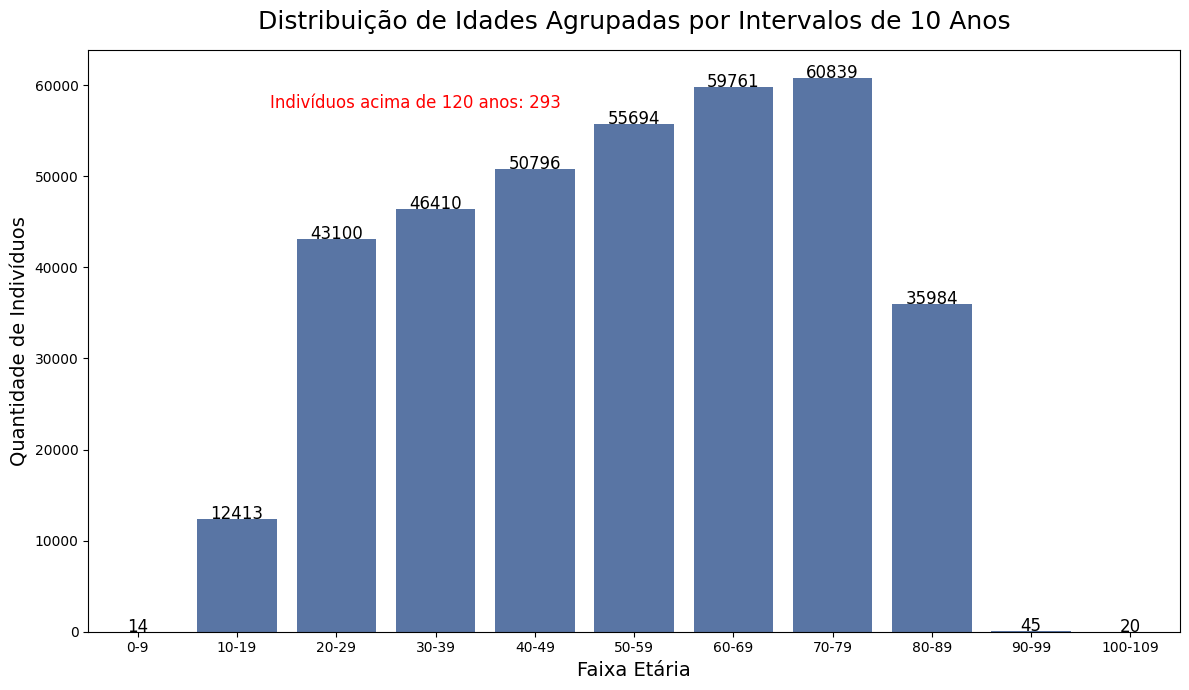

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtra registros com idade válida
valid_ages = df_records["age"].dropna()  # Remove valores NaN

# Conta a quantidade de indivíduos com idade acima de 120 anos
above_120_count = (valid_ages > 120).sum()

# Exibe a quantidade de indivíduos com idade acima de 120 anos
print(f"Quantidade de indivíduos com idade acima de 120 anos: {above_120_count}")

# Filtra os indivíduos com idade até 120 anos
valid_ages_filtered = valid_ages[valid_ages <= 120]

# Define os intervalos de idade (bins) de 10 em 10 anos
bins = range(int(valid_ages_filtered.min()) // 10 * 10, int(valid_ages_filtered.max()) + 11, 10)
labels = [f"{i}-{i+9}" for i in bins[:-1]]

# Agrupa as idades nos intervalos definidos
age_groups = pd.cut(valid_ages_filtered, bins=bins, labels=labels, right=False)

# Conta a frequência de cada grupo de idade
age_group_counts = age_groups.value_counts().sort_index()

# Cria o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x=age_group_counts.index, y=age_group_counts.values, color="#4c72b0")  # Azul claro para as barras

# Adiciona título e rótulos dos eixos
plt.title("Distribuição de Idades Agrupadas por Intervalos de 10 Anos", fontsize=18, pad=15)
plt.xlabel("Faixa Etária", fontsize=14)
plt.ylabel("Quantidade de Indivíduos", fontsize=14)

# Exibe os valores acima das barras
for i, count in enumerate(age_group_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', fontsize=12)

# Adiciona uma anotação para indicar a quantidade de indivíduos acima de 120 anos
if above_120_count > 0:
    plt.annotate(
        f"Indivíduos acima de 120 anos: {above_120_count}",
        xy=(0.3, 0.90),  # Posição relativa no gráfico
        xycoords="axes fraction",
        ha="center",
        fontsize=12,
        color="red"
    )

# Ajusta layout para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

Quantidade de indivíduos com idade acima de 120 anos: 293


/tmp/ipykernel_205401/666348686.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chagas_counts = df_filtered.groupby(['age_group', 'label']).size().unstack(fill_value=0)


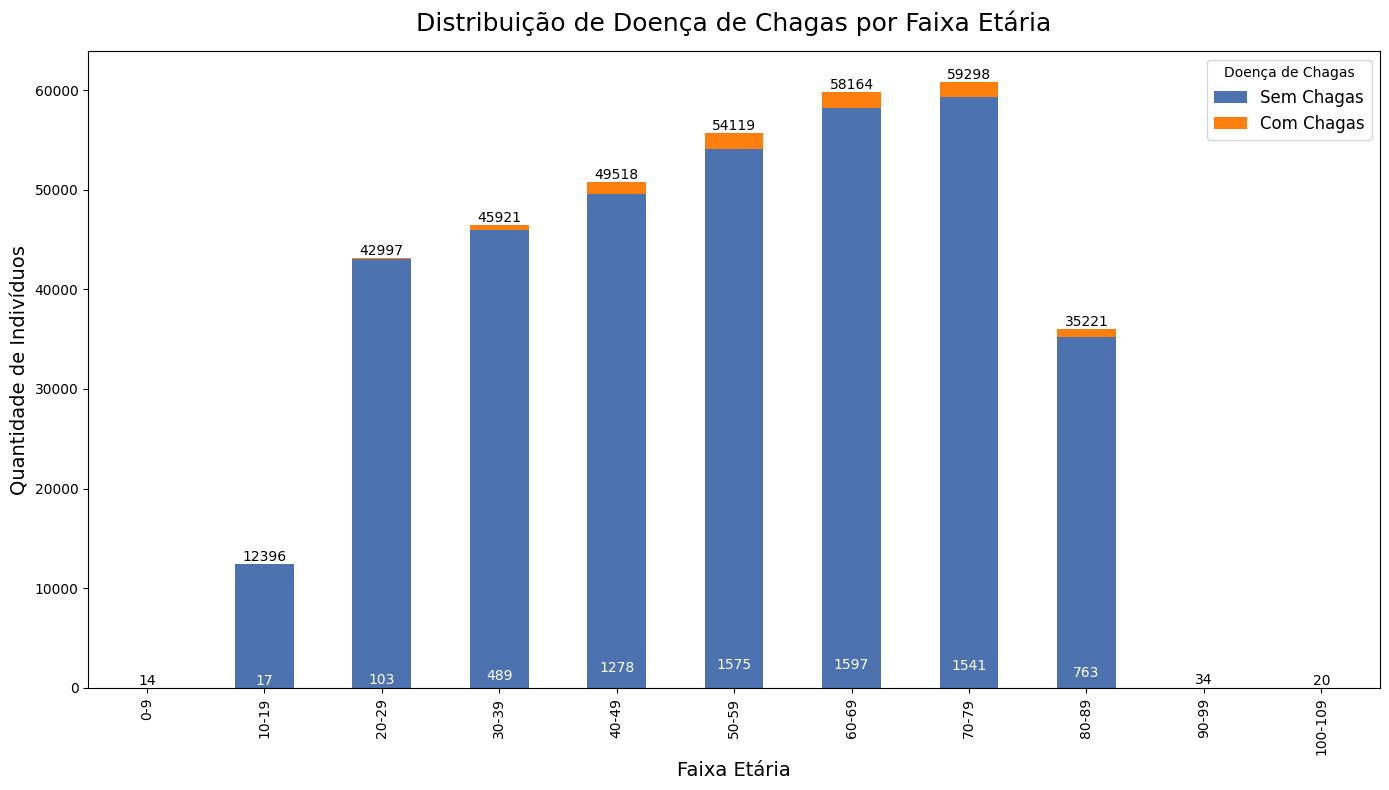

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtra registros com idade válida
valid_ages = df_records["age"].dropna()  # Remove valores NaN

# Conta a quantidade de indivíduos com idade acima de 120 anos
above_120_count = (valid_ages > 120).sum()

# Exibe a quantidade de indivíduos com idade acima de 120 anos
print(f"Quantidade de indivíduos com idade acima de 120 anos: {above_120_count}")

# Filtra os indivíduos com idade até 120 anos
valid_ages_filtered = valid_ages[valid_ages <= 120]

# Define os intervalos de idade (bins) de 10 em 10 anos
bins = range(int(valid_ages_filtered.min()) // 10 * 10, int(valid_ages_filtered.max()) + 11, 10)
labels = [f"{i}-{i+9}" for i in bins[:-1]]

# Cria uma cópia filtrada do DataFrame apenas com as idades válidas
df_filtered = df_records[df_records["age"].isin(valid_ages_filtered)].reset_index(drop=True)

# Agrupa as idades nos intervalos definidos
df_filtered['age_group'] = pd.cut(df_filtered['age'], bins=bins, labels=labels, right=False)

# Conta a quantidade de indivíduos com e sem Chagas em cada faixa etária
chagas_counts = df_filtered.groupby(['age_group', 'label']).size().unstack(fill_value=0)

# Renomeia as colunas para facilitar a interpretação
chagas_counts.rename(columns={0: "Sem Chagas", 1: "Com Chagas"}, inplace=True)

# Plota o gráfico de barras empilhadas
plt.figure(figsize=(14, 8))
ax = chagas_counts.plot(kind='bar', stacked=True, color=["#4c72b0", "#ff7f0e"], ax=plt.gca())

# Adiciona título e rótulos dos eixos
plt.title("Distribuição de Doença de Chagas por Faixa Etária", fontsize=18, pad=15)
plt.xlabel("Faixa Etária", fontsize=14)
plt.ylabel("Quantidade de Indivíduos", fontsize=14)

# Adiciona legenda
plt.legend(title="Doença de Chagas", loc="upper right", fontsize=12)

# Adiciona os valores acima das barras
for i, (index, row) in enumerate(chagas_counts.iterrows()):
    # Posição da classe "Com Chagas"
    if row["Com Chagas"] > 0:  # Verifica se há casos de Chagas
        ax.text(i, row["Com Chagas"] - 3, str(row["Com Chagas"]), ha='center', va='bottom', fontsize=10, color='white')

    # Posição da classe "Sem Chagas"
    total_height = row["Com Chagas"] + row["Sem Chagas"]
    if row["Sem Chagas"] > 0:  # Verifica se há casos sem Chagas
        ax.text(i, total_height + 3, str(row["Sem Chagas"]), ha='center', va='bottom', fontsize=10, color='black')

# Ajusta layout para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

### c. Distribuição por Sexo

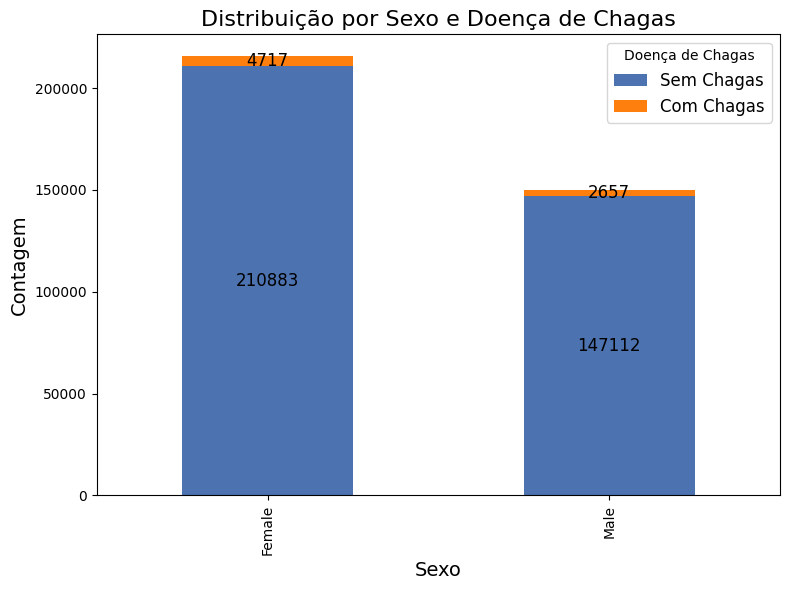

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem de indivíduos por sexo e rótulo (Com Chagas / Sem Chagas)
sex_chagas_counts = df_records.groupby(['sex', 'label']).size().unstack(fill_value=0)

# Renomeia as colunas para facilitar a interpretação
sex_chagas_counts.rename(columns={0: "Sem Chagas", 1: "Com Chagas"}, inplace=True)

# Plota o gráfico de barras empilhadas
plt.figure(figsize=(8, 6))
ax = sex_chagas_counts.plot(kind='bar', stacked=True, color=["#4c72b0", "#ff7f0e"], ax=plt.gca())

# Adiciona título e rótulos dos eixos
plt.title("Distribuição por Sexo e Doença de Chagas", fontsize=16)
plt.xlabel("Sexo", fontsize=14)
plt.ylabel("Contagem", fontsize=14)

# Adiciona legenda
plt.legend(title="Doença de Chagas", loc="upper right", fontsize=12)

# Adiciona os valores diretamente nas barras
for i, (index, row) in enumerate(sex_chagas_counts.iterrows()):
    cumulative_height = 0
    for value in row:
        if value > 0:  # Exibe apenas valores maiores que zero
            ax.text(i, cumulative_height + value / 2, str(value), ha='center', va='center', fontsize=12, color='black')
        cumulative_height += value

# Ajusta layout para evitar sobreposição
plt.tight_layout()

# Exibe o gráfico
plt.show()

### d. Análise Estatística dos Sinais ECG

In [59]:
def analyze_ecg_signals(record_path):
    signal, fields = wfdb.rdsamp(record_path)
    num_samples, num_channels = signal.shape
    
    stats = {
        "num_channels": num_channels,
        "num_samples": num_samples,
        "mean": np.mean(signal, axis=0),
        "median": np.median(signal, axis=0),
        "std": np.std(signal, axis=0),
        "min": np.min(signal, axis=0),
        "max": np.max(signal, axis=0)
    }
    return stats

# Aplica análise a alguns registros de exemplo
example_record = os.path.join(code15_output, df_records.iloc[0]["record"])
stats = analyze_ecg_signals(example_record)

# Exibe estatísticas
for key, value in stats.items():
    print(f"{key}: {value}")

num_channels: 12
num_samples: 4096
mean: [-0.45069214 -0.86440381 -0.41370898  0.65943018 -0.01667676 -0.63719141
  0.34451172  0.12496167  1.23819067  1.06939331  0.56570532  0.38456958]
median: [-0.518  -0.922  -0.457   0.724  -0.008  -0.674   0.365   0.152   1.187
  1.005   0.4835  0.299 ]
std: [0.22279674 0.27351698 0.1949386  0.22980275 0.15842981 0.20971951
 0.18629794 0.30407233 0.29210221 0.26483827 0.29680472 0.2661703 ]
min: [-0.866 -1.374 -1.269 -0.447 -0.396 -1.18  -0.631 -1.608  0.246  0.298
 -0.153 -0.069]
max: [0.703 0.473 0.243 1.093 0.877 0.321 0.664 0.803 2.671 2.686 2.404 2.024]


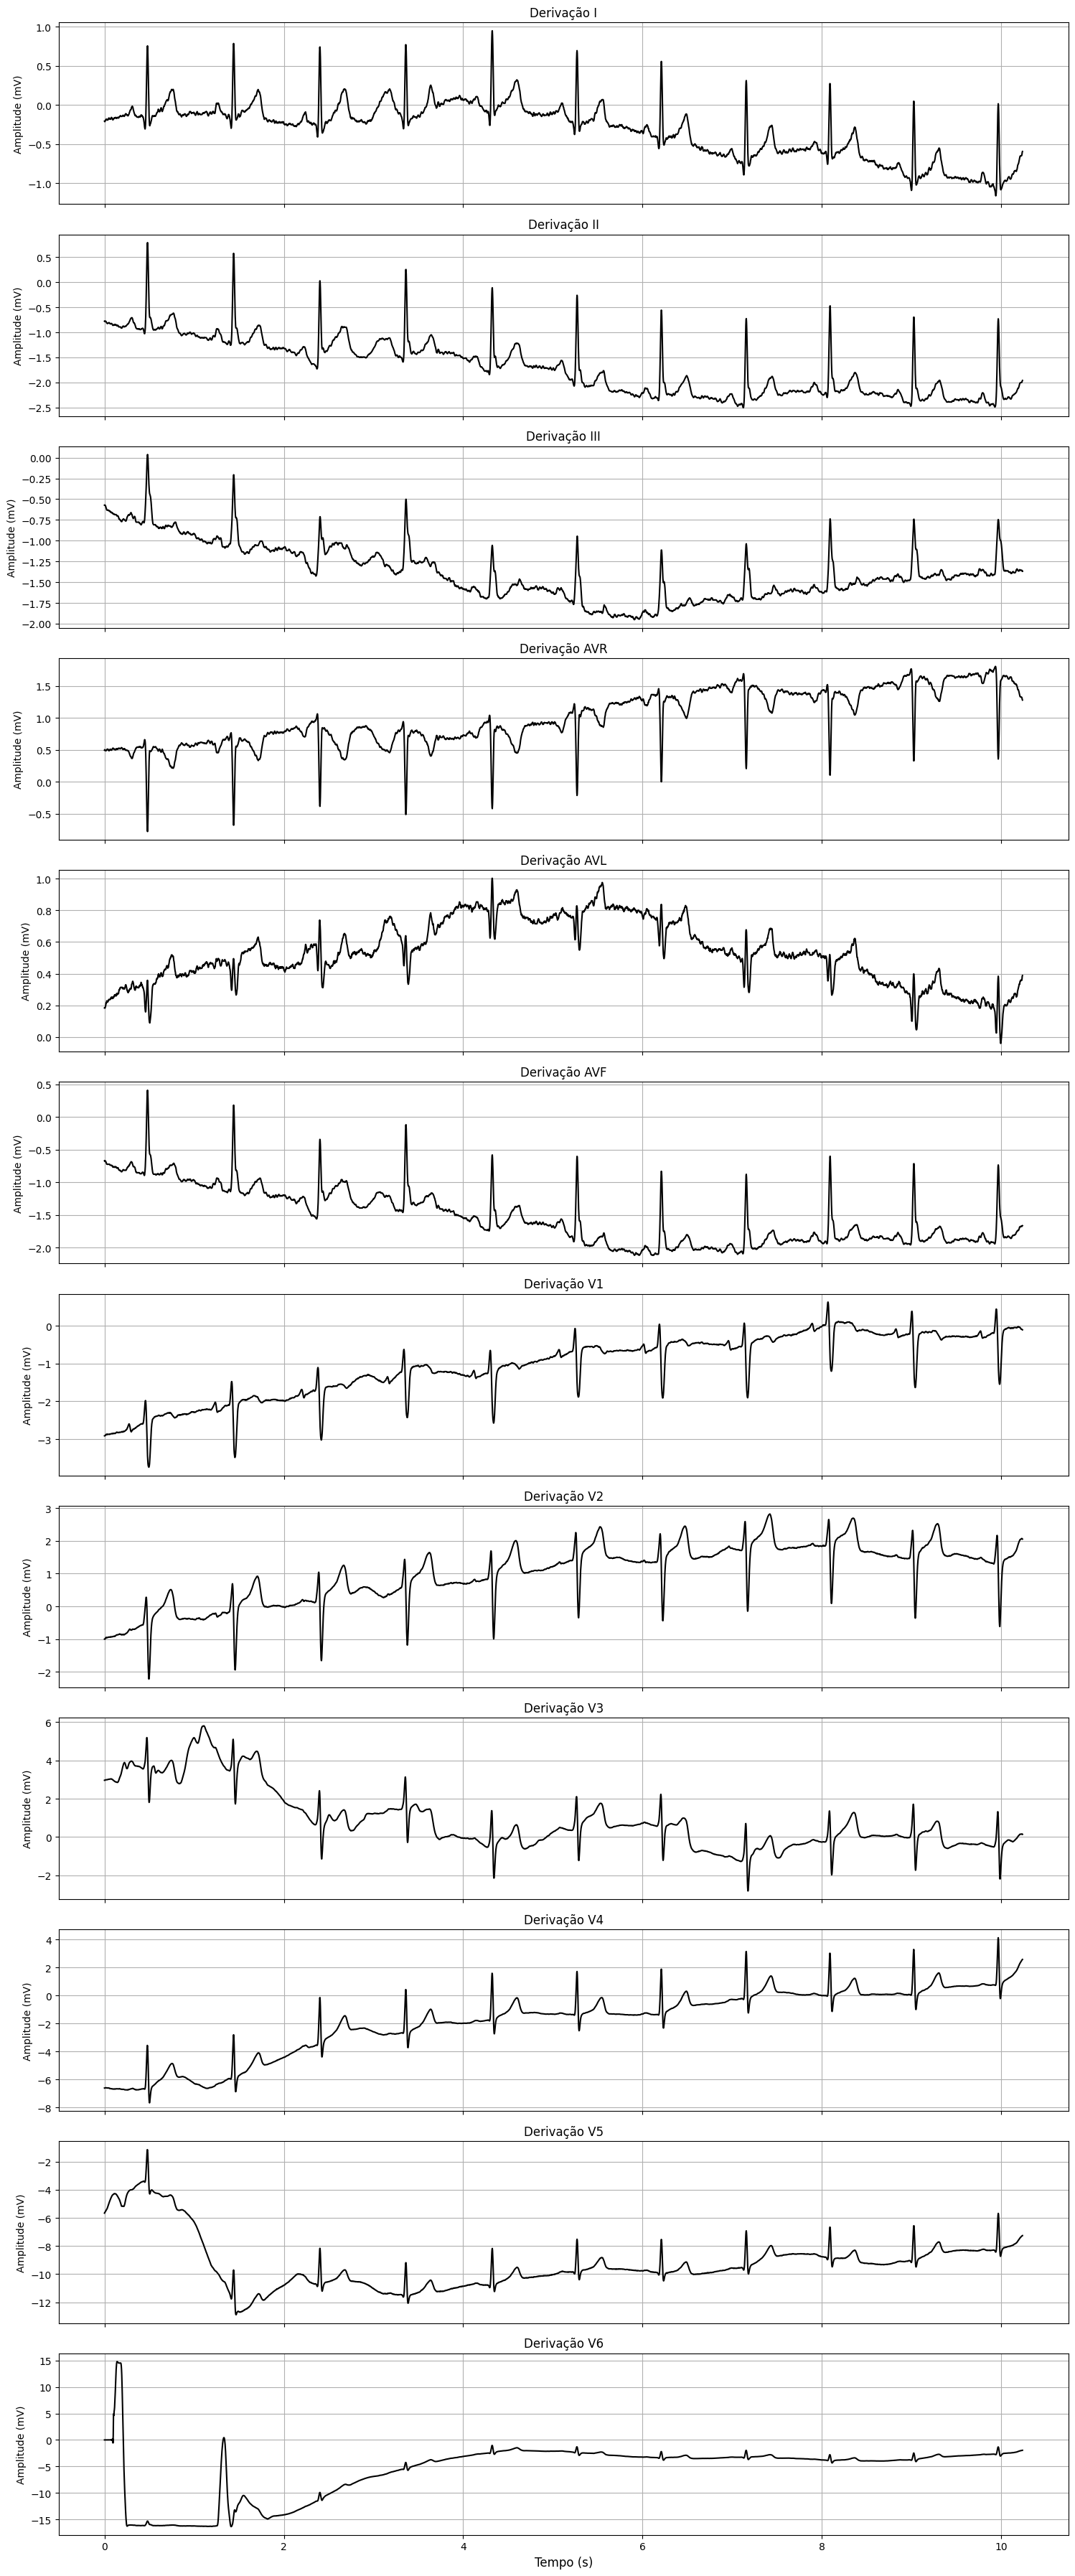

In [73]:
import matplotlib.pyplot as plt
import wfdb
import os

# Função para plotar as 12 derivações de um sinal ECG
def plot_ecg_signals(record_path, sampling_frequency=None):
    # Carrega o sinal e os metadados
    signal, fields = wfdb.rdsamp(record_path)
    num_samples, num_channels = signal.shape
    
    # Obtém os nomes das derivações (canais)
    lead_names = fields.get('sig_name', [f"Lead {i+1}" for i in range(num_channels)])
    
    # Define o tempo em segundos
    if sampling_frequency is None:
        sampling_frequency = fields.get('fs', 1)  # Frequência de amostragem padrão é 1 Hz se não estiver disponível
    time = np.arange(num_samples) / sampling_frequency
    
    # Cria subplots para cada derivação
    fig, axes = plt.subplots(num_channels, 1, figsize=(15, 3 * num_channels), sharex=True)
    
    # Plota cada derivação
    for i in range(num_channels):
        axes[i].plot(time, signal[:, i], color='black')
        axes[i].set_title(f"Derivação {lead_names[i]}", fontsize=12)
        axes[i].set_ylabel("Amplitude (mV)", fontsize=10)
        axes[i].grid(True)
    
    # Configura o eixo x compartilhado
    axes[-1].set_xlabel("Tempo (s)", fontsize=12)
    
    # Ajusta layout para evitar sobreposição
    plt.tight_layout()
    plt.show()

# Exemplo: Plota o sinal de um registro específico
example_record = os.path.join(code15_output, df_records.iloc[1]["record"])
plot_ecg_signals(example_record)

## 5. Divisão em training_data e holdout_data
Podemos criar índices virtuais para dividir os dados sem mover os arquivos físicos:

In [74]:
# Divide os dados em treino e validação (80% treino, 20% holdout)
train_df, holdout_df = train_test_split(df_records, test_size=0.2, stratify=df_records["label"], random_state=42)

# Salva os índices para referência futura
train_df.to_csv("training_data_indices.csv", index=False)
holdout_df.to_csv("holdout_data_indices.csv", index=False)

print("Training Data Size:", len(train_df))
print("Holdout Data Size:", len(holdout_df))

Training Data Size: 292295
Holdout Data Size: 73074


## 6. Função para Acesso aos Dados
Agora que temos os índices, podemos acessar os dados sem mover os arquivos:

In [ ]:
def get_record_path(record_info, base_path):
    return os.path.join(base_path, record_info["dataset"], record_info["record"])

# Exemplo: Acessar um registro de treino
example_train_record = train_df.iloc[0]
train_record_path = get_record_path(example_train_record, "")
print("Exemplo de Registro de Treino:", train_record_path)

# Exemplo: Acessar um registro de holdout
example_holdout_record = holdout_df.iloc[0]
holdout_record_path = get_record_path(example_holdout_record, "")
print("Exemplo de Registro de Holdout:", holdout_record_path)

## 6. Model Use